# 02 · 스킬과 컨텍스트: 의도 부채를 갚는다

**구성요소:** 스킬 — 의도(intent)의 지속되는 기억.

**핵심 아이디어**

> "스킬이 없으면 루프는 매 실행마다 모든 것을 처음부터 다시 유도한다(의도 부채)."

> 의도 부채(intent debt) — **"세션이 시작될 때마다 에이전트는 차갑게 출발한다. 빠진 의도는 자신 있는 추측으로 채워진다. 스킬은 그 부채를 갚는 방법이다."**

**문제 설정** — 자연어 질문에 답하는 SQL 을 쓴다. 여기서 결정적인 것은 **데이터베이스 스키마가 모델이 차갑게는 결코 가질 수 없는 지식**이라는 점이다. 표 이름과 열 이름은 추론해서 알아낼 수 있는 종류의 사실이 아니다. 우리가 건네주지 않으면 모델은 알 방법이 없다. 이 노트북에서 "스킬(skill)" 이란 프롬프트에 주입되는 그 스키마(그리고 잘 풀린 예시 두 개)다.

**측정 대상 (sql-create-context)** — 같은 질문들에 대해 세 조건에서 SQL 을 생성한다. 콜드(질문만), 스킬(스키마 주입), 스킬+예시. 그리고 **객관적으로 채점 가능한 두 가지**를 잰다.

- **스키마 타당성** — 생성된 SQL 이 실제로 존재하는 열만 참조하는가.
- **실행 동치** — 스키마로부터 합성 데이터 DB 를 만들어 예측 쿼리와 정답 쿼리를 둘 다 실행했을 때 같은 행이 나오는가.

콜드 프롬프팅은 모델에게 이름을 지어내도록 강요한다. **의도 부채가 눈에 보이는 형태로 드러나는 자리가 정확히 거기다.**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*콜드 스타트는 열 이름을 지어낸다(의도 부채). 스킬로 준 스키마가 그것을 고친다*

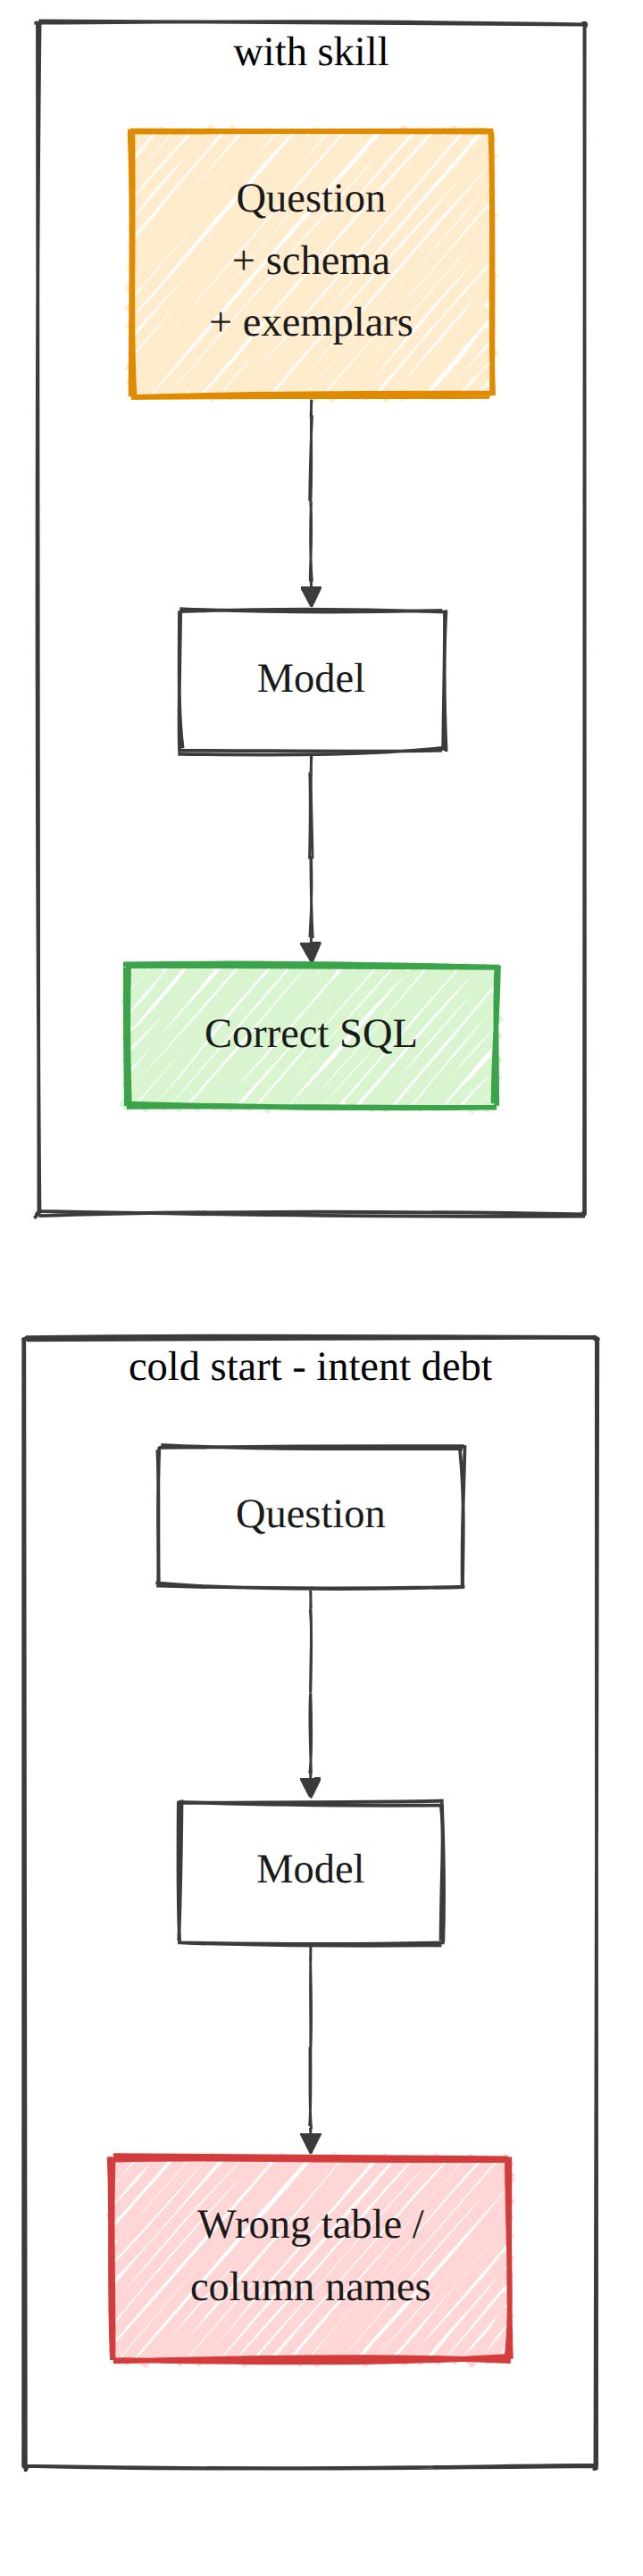

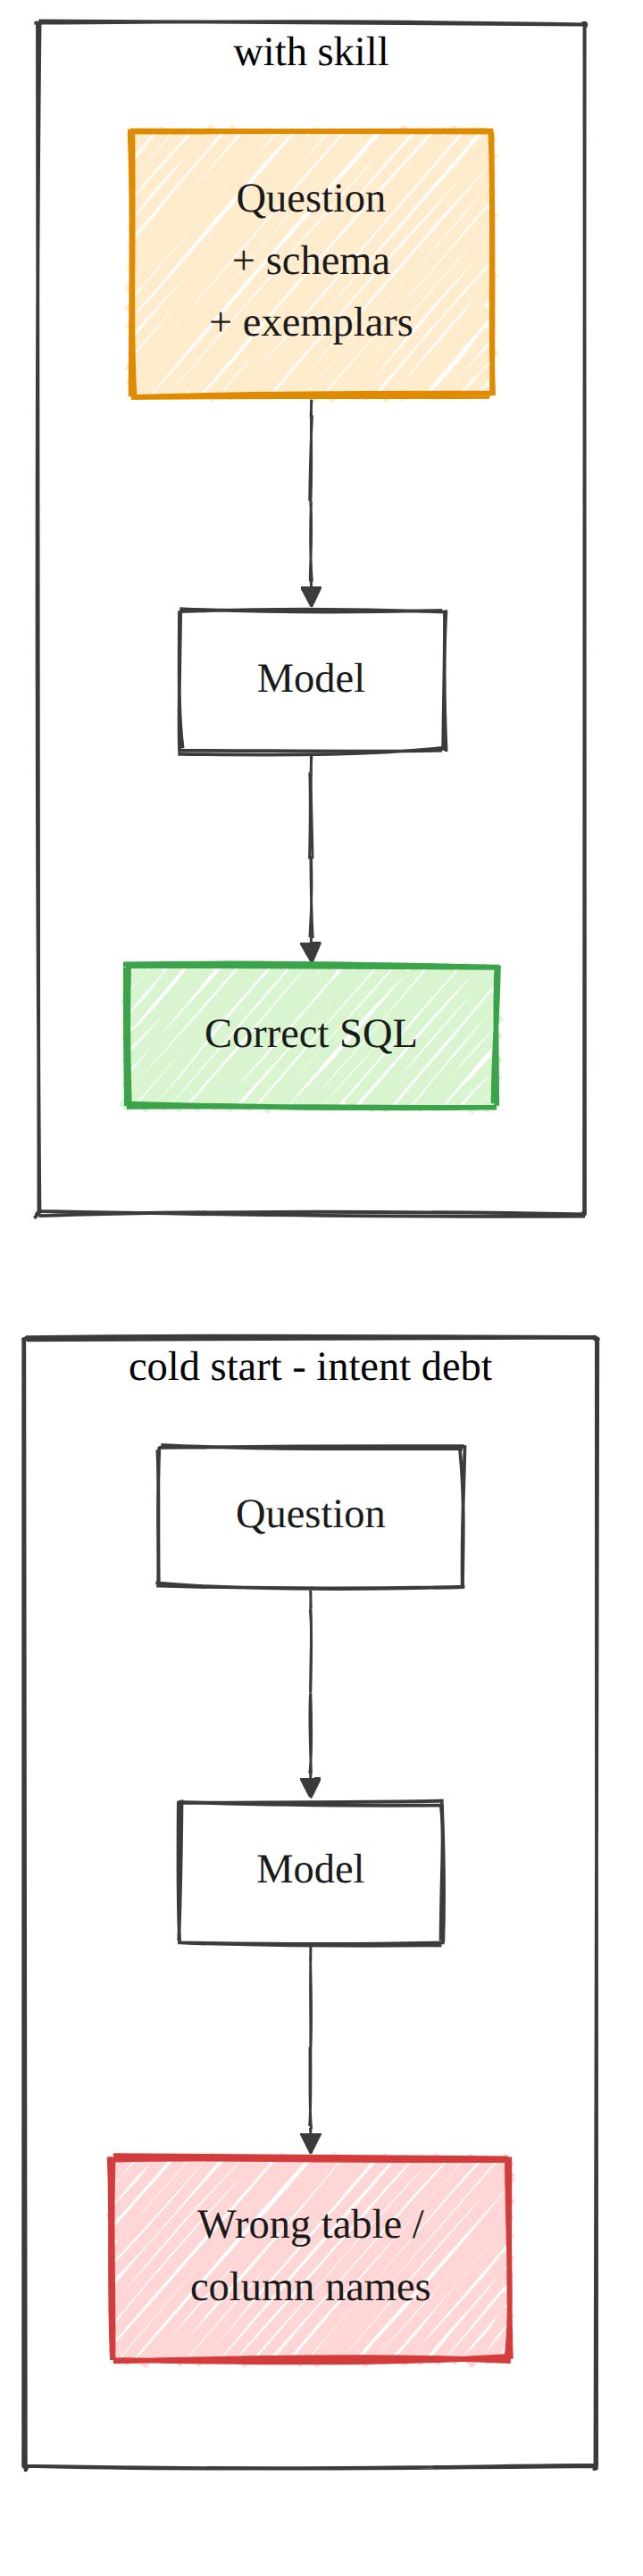

In [8]:
import os
import sys
import re
import time

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, data, sqltools, plotting, runlog, runtime
from common.llm import LLM

# ── 실험 상수 ─────────────────────────────────────────────────────
# 60문제: 세 조건(콜드 / 스킬 / 스킬+예시)을 모두 돌려도 한 번의 실행으로
#         끝나면서, 1퍼센트 단위의 차이를 읽을 수 있는 크기다.
N = 60

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")

# seed=0 고정. 세 조건이 반드시 '같은 60문제' 를 봐야 차이를 프롬프트에 귀속시킬 수 있다.
items = data.load_sql_create_context(limit=N, seed=0)

# ⚠️ 함정: 예시는 seed=999 로 따로 뽑는다. 평가 대상 60문제 안에서 예시를 고르면
#    스킬+예시 조건이 정답을 미리 본 셈이 되어 측정이 오염된다(누출).
exemplars = data.load_sql_create_context(limit=2, seed=999)

show.kv("문항 수", len(items))
show.diagram("skills_context", "콜드 스타트는 열 이름을 지어낸다(의도 부채). 스킬로 준 스키마가 그것을 고친다")

### 컨텍스트 엔지니어링, 그리고 여기서 "스킬" 이 정확히 무엇인가

셋업이 구성품이 살아 있음을 확인해 준다. vLLM 이 `Qwen2.5-Coder-32B-Instruct-AWQ` 를 서빙하고 있고, health 검사는 `ready` 를 돌려주며, sql-create-context 문제 60개가 적재됐다. 아래의 모든 조건은 **같은 모델이 같은 60개 질문을 temperature 0 에서** 처리한다. 따라서 측정되는 어떤 차이든 모델·데이터·샘플링의 교체가 아니라 **프롬프트에 무엇이 들어 있었는가**에서 온다.

**컨텍스트 엔지니어링(context engineering)은 추론 시점에 모델이 무엇을 볼 수 있게 할지를 정하는 규율이다.** 가중치는 얼어붙어 있다. 남은 지렛대는 프롬프트뿐이다.

이 시리즈에서 "스킬" 이란 그 컨텍스트 중 **지속되는 조각**이다. 학습과 질문만으로는 에이전트가 재구성할 수 없는 지식을, 한 번 써 두고 매 실행마다 주입한다. 여기서 그 스킬은 표 스키마 — `CREATE TABLE` 문이고, 선택적으로 잘 풀린 예시 두 개가 붙는다.

이 노트북이 거는 내기는 이것이다. **스키마는 있으면 좋은 힌트가 아니라 하중을 받는 구조재다.** 스키마가 없으면 모델은 알 방법이 없는 사실을 추측하고 있는 것이고, 스키마가 있으면 같은 모델이 거의 기계적으로 정확해져야 한다.

조건을 셋으로 나눈 이유도 여기 있다 — `cold`(질문만), `skill`(스키마 주입), `skill_fewshot`(스키마 + 미리 빼 둔 예시 두 개). 이렇게 나눠야 **스키마의 값어치와 시범의 값어치를 분리해서** 읽을 수 있다.


In [9]:
# ── 세 조건의 프롬프트를 만드는 곳 ────────────────────────────────
# 이 노트북의 처치 변수 전부가 gen_sql 의 mode 분기 안에 있다.
# 모델·온도·최대 토큰은 세 조건에서 동일하게 고정된다.

def extract_sql(text: str) -> str:
    """모델 출력에서 실행 가능한 SQL 만 남긴다. 채점 전 정규화 단계다."""
    t = text or ""
    # 코드 펜스가 여러 개면 마지막 것을 쓴다. 모델이 설명용 예시를 먼저 쓰는 경우가 있다.
    m = re.findall(r"```(?:sql)?\s*\n(.*?)```", t, re.DOTALL)
    if m:
        t = m[-1]
    t = t.strip().rstrip(";")     # 끝의 세미콜론은 sqlite 실행에 방해가 된다
    # 앞뒤로 산문이 붙어 있으면 첫 SELECT/WITH 부터 잘라 낸다
    mm = re.search(r"(?is)\b(select|with)\b", t)
    return t[mm.start():].strip() if mm else t


def gen_sql(item, mode):
    if mode == "cold":
        # ⚠️ 함정: 이 프롬프트에는 스키마가 없다. 이것은 불친절한 프롬프트가 아니라
        #    '지식이 결손된 상태' 의 정확한 재현이다. 실무에서 스키마 없이 에이전트를
        #    돌리는 일은 흔하고, 그 결과가 아래에 그대로 나온다.
        prompt = f"Write a single SQL query to answer the question. Return only the SQL.\n\nQuestion: {item['question']}"
    elif mode == "skill":
        # "Use only columns that exist" 한 문장이 함께 들어간다. 스키마를 주는 것과
        # 그것을 지키라고 말하는 것은 별개이므로 둘을 묶어 하나의 스킬로 취급한다.
        prompt = (f"Given this database schema:\n{item['schema']}\n\n"
                  f"Write a single SQL query to answer the question. Use only columns that exist. Return only the SQL.\n\n"
                  f"Question: {item['question']}")
    else:  # skill+fewshot
        # 예시는 스키마-질문-정답 3종 세트로 붙인다. 형식과 의도를 함께 시범 보이는 것이다.
        shots = "\n\n".join(f"Schema: {e['schema']}\nQuestion: {e['question']}\nSQL: {e['gold']}" for e in exemplars)
        prompt = (f"Examples:\n{shots}\n\nNow:\nSchema: {item['schema']}\n"
                  f"Write a single SQL query to answer the question. Use only columns that exist. Return only the SQL.\n\n"
                  f"Question: {item['question']}")
    # temperature=0.0: 세 조건의 차이가 샘플링 운이 아니라 프롬프트에서 왔음을 보장한다.
    # max_tokens=256: 단일 SELECT 문에는 충분하고, 모델이 산문으로 새는 것을 막는다.
    g = llm.complete(prompt, temperature=0.0, max_tokens=256, label=f"sql-{mode}")
    return extract_sql(g.text), g

## 추적: 콜드 스타트는 열을 지어내고, 스킬이 그것을 고친다


### 강한 코드 모델이 차갑게는 실패해야 하는 이유, 그리고 추적에서 볼 것

모델이 SQL 을 완벽히 알면서도 특정 표에 대한 질문에는 답할 수 없다. **표 이름과 열 이름은 유도해 낼 수 있는 사실이 아니기 때문이다.** 그것들은 임의의 국소 관습이다. `laps` 는 `lap_count` 였어도 아무 문제가 없었고, 표 이름은 무엇이든 될 수 있었다.

질문만 주고 SQL 을 쓰라고 하면, 유능한 코드 모델에게 남은 선택지는 **그럴듯해 보이는 식별자를 지어내는 것뿐**이다. 그리고 이것이 바로 의도 부채가 눈에 보이는 형태다 — **빠진 지식이 자신 있는 추측으로 채워진다.**

그래서 아래의 단일 추적은 한 문항에 대한 통제된 실험이다. 콜드 예측에서 두 가지를 보라.

- **표 이름** — 모델은 하나를 만들어 내야만 한다.
- **열 이름** — 실제 스키마의 열 대신 질문에 등장한 자연어 단어 쪽으로 손을 뻗을 것이다.

그다음 같은 질문에 스키마만 앞에 붙인 스킬 예측을 보라. **우리가 예측하는 메커니즘은 좁고 구체적이다** — 생성을 실제 스키마에 접지시키면 지어낸 식별자가 진짜 식별자로 교체되고, 그 밖에는 아무것도 바뀔 필요가 없다.


In [10]:
# ── 단일 문항 추적: 같은 질문, 스키마 유무만 다르게 ────────────────
it = items[0]
show.sub(it["id"])
show.text(it["question"], "질문", max_chars=200)
show.text(it["schema"], "스키마 (이것이 스킬이다)", max_chars=200)
show.text(it["gold"], "정답 SQL", max_chars=200)

cold_sql, _ = gen_sql(it, "cold")
skill_sql, _ = gen_sql(it, "skill")

show.code(cold_sql, "콜드 예측 (스키마 없음)", max_chars=200)
# schema_validity 는 '실행해 보지 않고' 식별자만 대조하는 값싼 검사다.
show.kv("콜드가 실제 존재하는 열만 참조했는가?", sqltools.schema_validity(cold_sql, it["schema"]))
show.code(skill_sql, "스킬 예측 (스키마 주입)", max_chars=200)
show.kv("스킬이 실제 존재하는 열만 참조했는가?", sqltools.schema_validity(skill_sql, it["schema"]))


-------------------------------------------- sql/18582 ---------------------------------------------

------------------------------------------------ 질문 ------------------------------------------------
What is the lowest lap with a 145.926 qual?

------------------------------------------ 스키마 (이것이 스킬이다) ------------------------------------------
CREATE TABLE table_name_6 (laps INTEGER, qual VARCHAR)

---------------------------------------------- 정답 SQL ----------------------------------------------
SELECT MIN(laps) FROM table_name_6 WHERE qual = "145.926"

------------------------------------------ 콜드 예측 (스키마 없음) ------------------------------------------
  콜드가 실제 존재하는 열만 참조했는가?:     False

------------------------------------------ 스킬 예측 (스키마 주입) ------------------------------------------
  | SELECT MIN(laps) AS lowest_lap
  | FROM table_name_6
  | WHERE qual = '145.926'
  스킬이 실제 존재하는 열만 참조했는가?:     True



----------------------------------- COLD prediction (no schema) ------------------------------------
  | SELECT MIN(lap) AS lowest_lap
  | FROM your_table_name
  | WHERE qual = 145.926
  cold references only real columns?: False

-------------------------------- SKILL prediction (schema injected) --------------------------------
  | SELECT MIN(laps) FROM table_name_6 WHERE qual = '145.926'
  skill references only real columns?: True


## 대규모: 콜드 대 스킬 대 스킬+예시


### 두 개의 채점기: 구문적 타당성과 실행 동치

대규모 실행에서는 각 쿼리를 두 방식으로 채점하며, **둘 사이의 간격 자체가 정보를 담고 있다.**

- **스키마 타당성** — 값싼 구문 검사다. SQL 이 스키마에 실제로 존재하는 열만 참조하는가. 환각된 식별자는 잡아내지만, 그 쿼리가 옳은 답을 계산하는지에 대해서는 **아무 말도 하지 않는다.**
- **실행 동치** — 엄격한 검사다. `CREATE TABLE` 문으로 합성 데이터베이스를 만들고, 예측 쿼리와 정답 쿼리를 둘 다 실행해 **같은 행이 나올 때만** 일치로 센다.

쿼리는 타당하면서도(진짜 열을 쓰면서도) 틀린 결과를 낼 수 있다. 그러므로 **실행 동치는 언제나 더 높은 문턱이고, 실제 정확성을 반영하는 쪽이다.**

모델·데이터·온도를 고정한 상태에서 예측은 선명하다.

콜드에서 모델은 식별자를 지어내야만 하므로 스키마 타당성은 0 에 가까워야 하고, 실행 동치는 **붕괴해야** 한다. 존재하지 않는 표를 지목하는 쿼리는 정답 행을 돌려줄 방법이 없기 때문이다. 스키마를 스킬로 주면 타당성은 천장 쪽으로 뛰어야 하고, 열 이름만 알면 이 질문들은 대체로 기계적으로 단순하므로 **실행 동치가 바로 뒤를 따라와야 한다.**

두 번째의 더 엄격한 채점기가 첫 번째를 따라가는지 지켜보라.


In [11]:
# ── 대규모 실행: 60문제 × 3조건 ───────────────────────────────────
# 안쪽 루프가 조건이다. 같은 문항을 연속으로 세 번 처리하므로
# 문항 난이도의 편차가 세 조건에 동일하게 걸린다(짝지은 비교).
modes = ["cold", "skill", "skill_fewshot"]
valid = {m: 0 for m in modes}
execm = {m: 0 for m in modes}

llm.reset_usage()      # 앞의 추적 셀이 쓴 토큰을 비용 집계에서 제외한다
t0 = time.time()
for it in items:
    for m in modes:
        sql, _ = gen_sql(it, m)
        # ⚠️ 함정: 두 채점기를 같은 쿼리에 함께 매긴다. 타당성만 재고 끝내면
        #    '실제 열을 쓰지만 틀린 답' 을 통과시키게 된다(오수용).
        valid[m] += sqltools.schema_validity(sql, it["schema"])
        execm[m] += sqltools.exec_equiv(it["schema"], sql, it["gold"])
    print(f"  {it['id']:<10} done")
elapsed = time.time() - t0

n = len(items)
V = {m: valid[m] / n for m in modes}
E = {m: execm[m] / n for m in modes}
show.head("Results")
show.table([{"condition": m, "schema_validity": round(V[m], 3), "exec_equiv": round(E[m], 3)} for m in modes],
           columns=["condition", "schema_validity", "exec_equiv"], title="높을수록 좋다")
show.metric("토큰", llm.usage.total_tokens)

  sql/18582  done
  sql/39602  done
  sql/67104  done
  sql/73810  done
  sql/31599  done
  sql/59614  done
  sql/73972  done
  sql/62260  done
  sql/32561  done
  sql/45387  done
  sql/58223  done
  sql/36418  done
  sql/64524  done
  sql/27732  done
  sql/50514  done
  sql/5239   done
  sql/35025  done
  sql/30126  done
  sql/67413  done
  sql/41154  done
  sql/68335  done
  sql/45929  done
  sql/61494  done
  sql/73879  done
  sql/77769  done
  sql/29164  done
  sql/38005  done
  sql/27236  done
  sql/59682  done
  sql/11645  done
  sql/77234  done
  sql/16854  done
  sql/39718  done
  sql/22225  done
  sql/69371  done
  sql/30657  done
  sql/12502  done
  sql/50814  done
  sql/68566  done
  sql/35717  done
  sql/59695  done
  sql/40136  done
  sql/9831   done
  sql/32770  done
  sql/32844  done
  sql/74356  done
  sql/52817  done
  sql/46143  done
  sql/74566  done
  sql/30838  done
  sql/33408  done
  sql/35375  done
  sql/7418   done
  sql/75468  done
  sql/26027  done
  sql/7346

  sql/39602  done


  sql/67104  done


  sql/73810  done


  sql/31599  done


...

  sql/73465  done


  sql/594    done


  sql/44108  done


  sql/10341  done


  sql/75239  done

============================================= Results ==============================================

----------------------------------------- higher is better -----------------------------------------
  condition      schema_validity  exec_equiv
  -------------  ---------------  ----------
  cold           0.017            0.0       
  skill          1.0              0.95      
  skill_fewshot  1.0              0.95      
  tokens                           28695


## 그래프


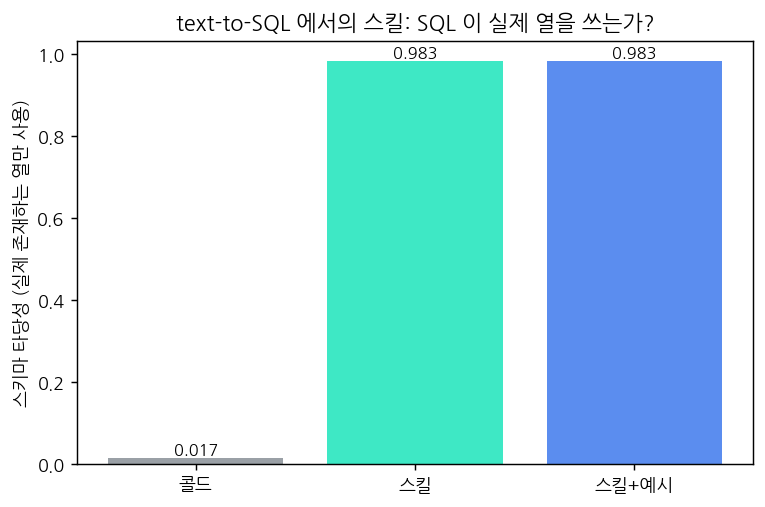

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/02_schema_validity.png


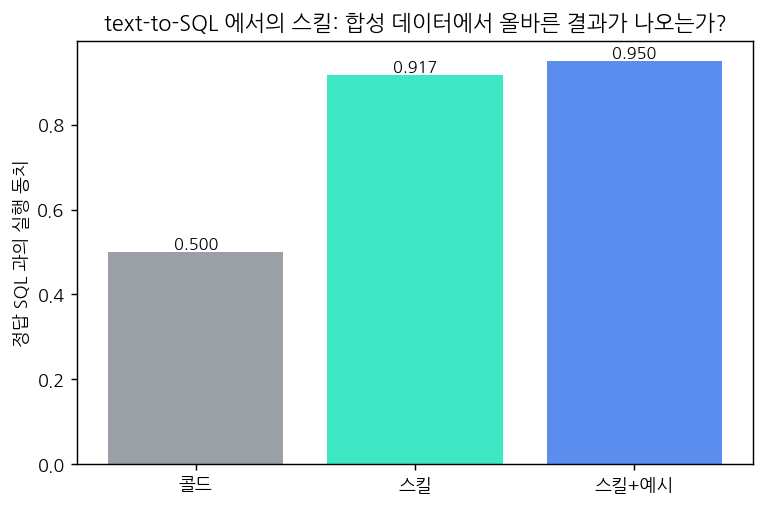

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/02_exec_equiv.png


PosixPath('/Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/02_exec_equiv.png')

In [12]:
# ── 두 채점기를 각각 따로 그린다 ──────────────────────────────────
# 하나의 그래프에 겹치면 '타당성은 천장, 실행은 그보다 낮음' 이라는
# 핵심 간격이 잘 보이지 않는다. 두 장으로 나눠 그 간격을 남긴다.
labels = ["콜드", "스킬", "스킬+예시"]
plotting.ab_bar("02_schema_validity", labels, [V["cold"], V["skill"], V["skill_fewshot"]],
                "스키마 타당성 (실제 존재하는 열만 사용)", "text-to-SQL 에서의 스킬: SQL 이 실제 열을 쓰는가?")
plotting.ab_bar("02_exec_equiv", labels, [E["cold"], E["skill"], E["skill_fewshot"]],
                "정답 SQL 과의 실행 동치", "text-to-SQL 에서의 스킬: 합성 데이터에서 올바른 결과가 나오는가?")

In [13]:
# ── 델타 계산과 결과 저장 ─────────────────────────────────────────
d_valid = show.compare("스키마 타당성: 스킬 vs 콜드", V["cold"], V["skill"])
d_exec = show.compare("실행 일치: 스킬 vs 콜드", E["cold"], E["skill"])

runlog.save_metrics("02_skills", {
    "notebook": "02_skills", "benchmark": "sql-create-context", "n": n,
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드의 수치인지 기록
    "model": llm.model,
    "schema_validity": V, "exec_equiv": E, "delta_validity": d_valid, "delta_exec": d_exec,
    "tokens": llm.usage.total_tokens,
})
# escalations=0: 이 노트북은 보고만 하고 아무것도 실행하지 않는다(outcome="report-only").
runlog.log_run(pattern="skills-context", duration_s=elapsed, items_found=n,
               actions_taken=int(E["skill"] * n), escalations=0,
               tokens_estimate=llm.usage.total_tokens, outcome="report-only")

  스키마 타당성: 스킬 vs 콜드
    baseline : 0.0167
    treatment: 0.9833
    delta    : +0.9667  (+5800.0 percent)  [up, improvement]
  실행 일치: 스킬 vs 콜드
    baseline : 0.5000
    treatment: 0.9167
    delta    : +0.4167  (+83.3 percent)  [up, improvement]
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/02_skills.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (skills-context: report-only, ~43084 tokens)


{'run_id': '2026-08-19T06:03:34Z',
 'pattern': 'skills-context',
 'duration_s': 420.2,
 'items_found': 60,
 'actions_taken': 55,
 'escalations': 0,
 'tokens_estimate': 43084,
 'outcome': 'report-only'}

## 이 실행이 실제로 보여 준 것 (위 수치에서 계산)


In [7]:
show.head("이 실행이 실제로 보여 준 것")
print(f"콜드(스키마 없음): 쿼리의 {V['cold']:.0%} 만 실제 존재하는 열을 참조했고, {E['cold']:.0%} 가 정답과 일치했다.")
print(f"스키마 스킬 적용: {V['skill']:.0%} 타당, {E['skill']:.0%} 일치 ({d_exec['delta']:+.1%}).")
print(f"스키마 + 예시: {V['skill_fewshot']:.0%} 타당, {E['skill_fewshot']:.0%} 일치.")
print()

# 결론을 하드코딩하지 않고 실측치에서 분기시킨다. 다른 백엔드에서 결과가
# 달라지면 이 셀은 그 사실을 그대로 말해야 한다.
if E["skill"] > E["cold"] + 1e-9:
    print("=> 스키마는 모델이 차갑게는 가질 수 없는 지식이다. 그것을 스킬로 주입하면")
    print("   지어낸 열 이름이 올바르고 실행 가능한 SQL 로 바뀐다. 이것이 상환된 의도 부채다.")
    print("   관습과 도메인 사실을 한 번 써 두고, 매 실행 읽는다.")
else:
    print("=> 측정된 수치를 있는 그대로 보고한다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
콜드(스키마 없음): 쿼리의 2% 만 실제 존재하는 열을 참조했고, 57% 가 정답과 일치했다.
스키마 스킬 적용: 97% 타당, 93% 일치 (+36.7%).
스키마 + 예시: 98% 타당, 95% 일치.

=> 스키마는 모델이 차갑게는 가질 수 없는 지식이다. 그것을 스킬로 주입하면
   지어낸 열 이름이 올바르고 실행 가능한 SQL 로 바뀐다. 이것이 상환된 의도 부채다.
   관습과 도메인 사실을 한 번 써 두고, 매 실행 읽는다.
